# Final Project

## Predict whether a mammogram mass is benign or malignant

We'll be using the "mammographic masses" public dataset from the UCI repository (source: https://archive.ics.uci.edu/ml/datasets/Mammographic+Mass)

This data contains 961 instances of masses detected in mammograms, and contains the following attributes:


   1. BI-RADS assessment: 1 to 5 (ordinal)  
   2. Age: patient's age in years (integer)
   3. Shape: mass shape: round=1 oval=2 lobular=3 irregular=4 (nominal)
   4. Margin: mass margin: circumscribed=1 microlobulated=2 obscured=3 ill-defined=4 spiculated=5 (nominal)
   5. Density: mass density high=1 iso=2 low=3 fat-containing=4 (ordinal)
   6. Severity: benign=0 or malignant=1 (binominal)
   
BI-RADS is an assesment of how confident the severity classification is; it is not a "predictive" attribute and so we will discard it. The age, shape, margin, and density attributes are the features that we will build our model with, and "severity" is the classification we will attempt to predict based on those attributes.

Although "shape" and "margin" are nominal data types, which sklearn typically doesn't deal with well, they are close enough to ordinal that we shouldn't just discard them. The "shape" for example is ordered increasingly from round to irregular.

A lot of unnecessary anguish and surgery arises from false positives arising from mammogram results. If we can build a better way to interpret them through supervised machine learning, it could improve a lot of lives.

## Your assignment

Apply several different supervised machine learning techniques to this data set, and see which one yields the highest accuracy as measured with K-Fold cross validation (K=10). Apply:

* Decision tree
* Random forest
* KNN
* Naive Bayes
* SVM
* Logistic Regression
* And, as a bonus challenge, a neural network using Keras.

The data needs to be cleaned; many rows contain missing data, and there may be erroneous data identifiable as outliers as well.

Remember some techniques such as SVM also require the input data to be normalized first.

Many techniques also have "hyperparameters" that need to be tuned. Once you identify a promising approach, see if you can make it even better by tuning its hyperparameters.

I was able to achieve over 80% accuracy - can you beat that?

Below I've set up an outline of a notebook for this project, with some guidance and hints. If you're up for a real challenge, try doing this project from scratch in a new, clean notebook!


## Let's begin: prepare your data

Start by importing the mammographic_masses.data.txt file into a Pandas dataframe (hint: use read_csv) and take a look at it.

In [2]:
import numpy as np
import pandas as pd
df_data = pd.read_csv('mammographic_masses.data.txt')
df_data.head()

,5,67,3,5.1,3.1,1
0,4,43,1,1,?,1
1,5,58,4,5,3,1
2,4,28,1,1,3,0
3,5,74,1,5,?,1
4,4,65,1,?,3,0


Make sure you use the optional parmaters in read_csv to convert missing data (indicated by a ?) into NaN, and to add the appropriate column names (BI_RADS, age, shape, margin, density, and severity):

In [3]:
df_data = pd.read_csv('mammographic_masses.data.txt', na_values=['?'], names = ['BI-RADS', 'age', 'shape', 'margin', 'density', 'severity'])
df_data.head()

,BI-RADS,age,shape,margin,density,severity
0,5.0,67.0,3.0,5.0,3.0,1
1,4.0,43.0,1.0,1.0,NaN,1
2,5.0,58.0,4.0,5.0,3.0,1
3,4.0,28.0,1.0,1.0,3.0,0
4,5.0,74.0,1.0,5.0,NaN,1


Evaluate whether the data needs cleaning; your model is only as good as the data it's given. Hint: use describe() on the dataframe.

In [4]:
df_data.describe()

,BI-RADS,age,shape,margin,density,severity
count,959.000000,956.000000,930.000000,913.000000,885.000000,961.000000
mean,4.348279,55.487448,2.721505,2.796276,2.910734,0.463059
std,1.783031,14.480131,1.242792,1.566546,0.380444,0.498893
min,0.000000,18.000000,1.000000,1.000000,1.000000,0.000000
25%,4.000000,45.000000,2.000000,1.000000,3.000000,0.000000
50%,4.000000,57.000000,3.000000,3.000000,3.000000,0.000000
75%,5.000000,66.000000,4.000000,4.000000,3.000000,1.000000
max,55.000000,96.000000,4.000000,5.000000,4.000000,1.000000


There are quite a few missing values in the data set. Before we just drop every row that's missing data, let's make sure we don't bias our data in doing so. Does there appear to be any sort of correlation to what sort of data has missing fields? If there were, we'd have to try and go back and fill that data in.

In [5]:
missing_rows = df_data[['age','shape','margin','density']].isnull().any(axis=1)
df_data[missing_rows]

,BI-RADS,age,shape,margin,density,severity
1,4.0,43.0,1.0,1.0,NaN,1
4,5.0,74.0,1.0,5.0,NaN,1
5,4.0,65.0,1.0,NaN,3.0,0
6,4.0,70.0,NaN,NaN,3.0,0
7,5.0,42.0,1.0,NaN,3.0,0
...,...,...,...,...,...,...
778,4.0,60.0,NaN,4.0,3.0,0
819,4.0,35.0,3.0,NaN,2.0,0
824,6.0,40.0,NaN,3.0,4.0,1
884,5.0,NaN,4.0,4.0,3.0,1


If the missing data seems randomly distributed, go ahead and drop rows with missing data. Hint: use dropna().

In [6]:
df_data.dropna(inplace = True)
df_data.describe()

,BI-RADS,age,shape,margin,density,severity
count,830.000000,830.000000,830.000000,830.000000,830.000000,830.000000
mean,4.393976,55.781928,2.781928,2.813253,2.915663,0.485542
std,1.888371,14.671782,1.242361,1.567175,0.350936,0.500092
min,0.000000,18.000000,1.000000,1.000000,1.000000,0.000000
25%,4.000000,46.000000,2.000000,1.000000,3.000000,0.000000
50%,4.000000,57.000000,3.000000,3.000000,3.000000,0.000000
75%,5.000000,66.000000,4.000000,4.000000,3.000000,1.000000
max,55.000000,96.000000,4.000000,5.000000,4.000000,1.000000


Next you'll need to convert the Pandas dataframes into numpy arrays that can be used by scikit_learn. Create an array that extracts only the feature data we want to work with (age, shape, margin, and density) and another array that contains the classes (severity). You'll also need an array of the feature name labels.

In [7]:
import numpy as np

X = df_data[['age', 'shape', 'margin', 'density']].values

y = df_data['severity'].values

feature_names = ['age', 'shape', 'margin', 'density']
X

array([[67.,  3.,  5.,  3.],
       [58.,  4.,  5.,  3.],
       [28.,  1.,  1.,  3.],
       ...,
       [64.,  4.,  5.,  3.],
       [66.,  4.,  5.,  3.],
       [62.,  3.,  3.,  3.]], shape=(830, 4))

Some of our models require the input data to be normalized, so go ahead and normalize the attribute data. Hint: use preprocessing.StandardScaler().

In [8]:
from sklearn import preprocessing

scaler = preprocessing.StandardScaler()
X_features = scaler.fit_transform(X)
X_features

array([[ 0.7650629 ,  0.17563638,  1.39618483,  0.24046607],
       [ 0.15127063,  0.98104077,  1.39618483,  0.24046607],
       [-1.89470363, -1.43517241, -1.157718  ,  0.24046607],
       ...,
       [ 0.56046548,  0.98104077,  1.39618483,  0.24046607],
       [ 0.69686376,  0.98104077,  1.39618483,  0.24046607],
       [ 0.42406719,  0.17563638,  0.11923341,  0.24046607]],
      shape=(830, 4))

## Decision Trees

Before moving to K-Fold cross validation and random forests, start by creating a single train/test split of our data. Set aside 75% for training, and 25% for testing.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (622, 4), Test: (208, 4)


Now create a DecisionTreeClassifier and fit it to your training data.

In [10]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Display the resulting decision tree.

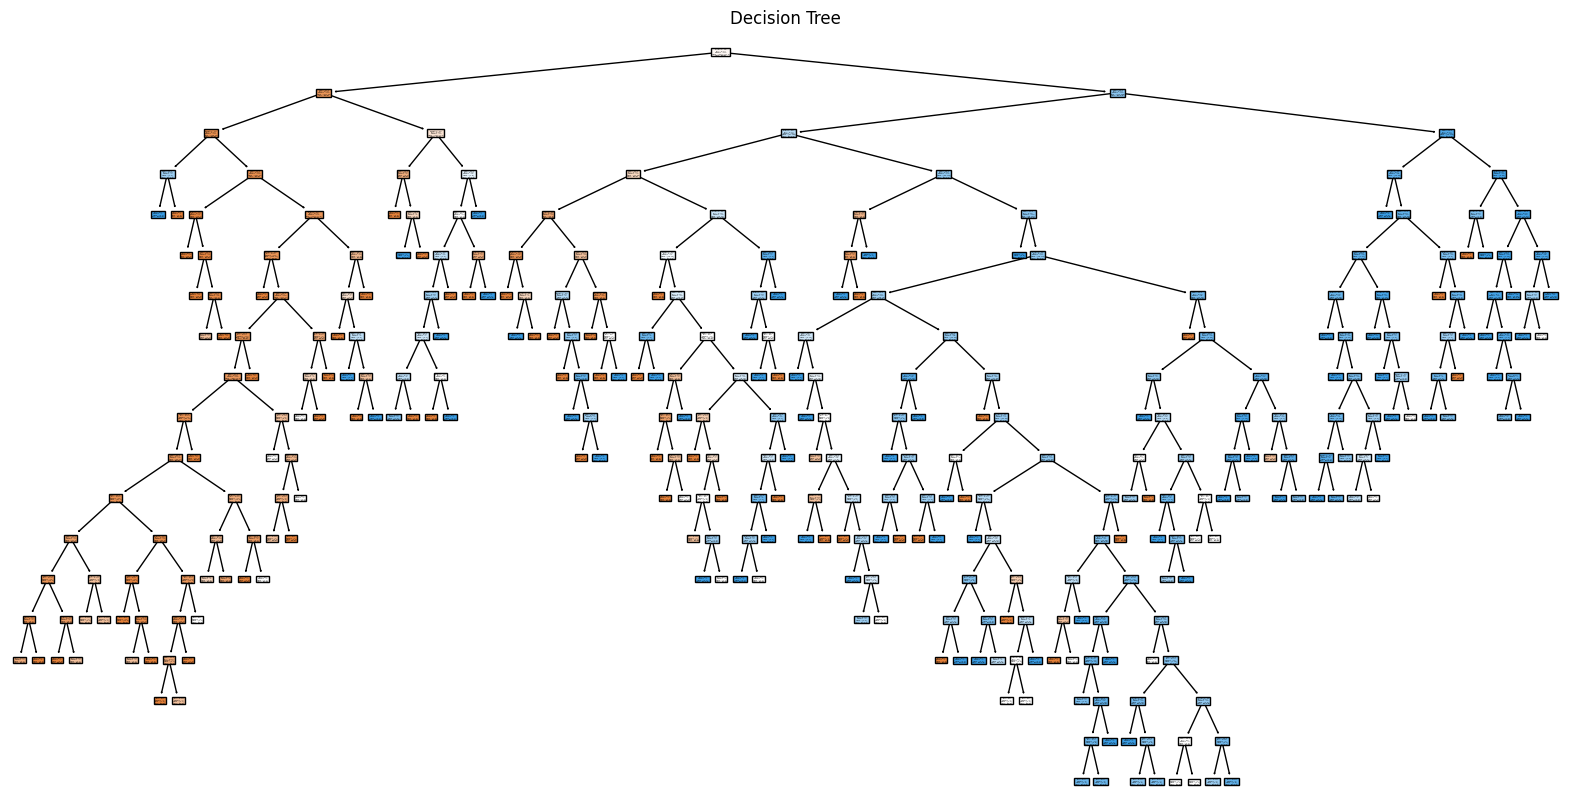

In [11]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=feature_names, class_names=['Benign', 'Malignant'], filled=True)
plt.title("Decision Tree")
plt.show()

Measure the accuracy of the resulting decision tree model using your test data.

In [12]:
from sklearn.metrics import accuracy_score

y_pred = dt.predict(X_test)
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Decision Tree Accuracy: 0.7644


Now instead of a single train/test split, use K-Fold cross validation to get a better measure of your model's accuracy (K=10). Hint: use model_selection.cross_val_score

In [13]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(dt, X, y, cv=kf, scoring='accuracy')
print(f"K-Fold Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

K-Fold Accuracy: 0.7361 ± 0.0359


Now try a RandomForestClassifier instead. Does it perform better?

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
scores_rf = cross_val_score(rf, X, y, cv=kf, scoring='accuracy')
print(f"Random Forest K-Fold Accuracy: {scores_rf.mean():.4f} ± {scores_rf.std():.4f}")

Random Forest K-Fold Accuracy: 0.7747 ± 0.0467


## SVM

Next try using svm.SVC with a linear kernel. How does it compare to the decision tree?

In [15]:
from sklearn.svm import SVC

svm = SVC(kernel='linear')
scores_svm = cross_val_score(svm, X_features, y, cv=kf, scoring='accuracy')
print(f"SVM (linear) K-Fold Accuracy: {scores_svm.mean():.4f} ± {scores_svm.std():.4f}")

SVM (linear) K-Fold Accuracy: 0.8000 ± 0.0400


## KNN
How about K-Nearest-Neighbors? Hint: use neighbors.KNeighborsClassifier - it's a lot easier than implementing KNN from scratch like we did earlier in the course. Start with a K of 10. K is an example of a hyperparameter - a parameter on the model itself which may need to be tuned for best results on your particular data set.

In [16]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=10)
scores_knn = cross_val_score(knn, X_features, y, cv=kf, scoring='accuracy')
print(f"KNN (K=10) Accuracy: {scores_knn.mean():.4f} ± {scores_knn.std():.4f}")

KNN (K=10) Accuracy: 0.7819 ± 0.0282


Choosing K is tricky, so we can't discard KNN until we've tried different values of K. Write a for loop to run KNN with K values ranging from 1 to 50 and see if K makes a substantial difference. Make a note of the best performance you could get out of KNN.

Best K: 23 with Accuracy: 0.7976


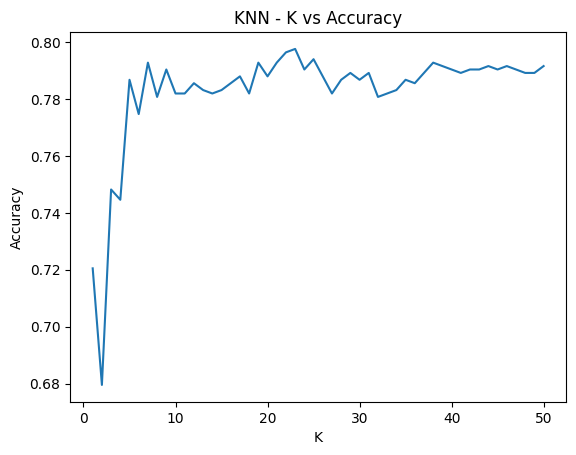

In [17]:
k_scores = []
for k in range(1, 51):
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_features, y, cv=kf, scoring='accuracy').mean()
    k_scores.append(score)

best_k = k_scores.index(max(k_scores)) + 1
print(f"Best K: {best_k} with Accuracy: {max(k_scores):.4f}")

import matplotlib.pyplot as plt
plt.plot(range(1, 51), k_scores)
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('KNN - K vs Accuracy')
plt.show()

## Naive Bayes

Now try naive_bayes.MultinomialNB. How does its accuracy stack up? Hint: you'll need to use MinMaxScaler to get the features in the range MultinomialNB requires.

In [18]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler

scaler_mm = MinMaxScaler()
X_minmax = scaler_mm.fit_transform(X)

nb = MultinomialNB()
scores_nb = cross_val_score(nb, X_minmax, y, cv=kf, scoring='accuracy')
print(f"Naive Bayes Accuracy: {scores_nb.mean():.4f} ± {scores_nb.std():.4f}")

Naive Bayes Accuracy: 0.7699 ± 0.0302


## Revisiting SVM

svm.SVC may perform differently with different kernels. The choice of kernel is an example of a "hyperparamter." Try the rbf, sigmoid, and poly kernels and see what the best-performing kernel is. Do we have a new winner?

In [19]:
for kernel in ['rbf', 'sigmoid', 'poly']:
    svm = SVC(kernel=kernel)
    scores = cross_val_score(svm, X_features, y, cv=kf, scoring='accuracy')
    print(f"SVM ({kernel}): {scores.mean():.4f} ± {scores.std():.4f}")

SVM (rbf): 0.8000 ± 0.0448
SVM (sigmoid): 0.7325 ± 0.0413
SVM (poly): 0.7807 ± 0.0369


## Logistic Regression

We've tried all these fancy techniques, but fundamentally this is just a binary classification problem. Try Logisitic Regression, which is a simple way to tackling this sort of thing.

In [33]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
cv_scores = cross_val_score(clf, all_features_scaled, all_classes, cv=10)
cv_scores.mean()

NameError: name 'all_features_scaled' is not defined

In [24]:
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print(f"Logistic Regression Test Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")

Logistic Regression Test Accuracy: 0.8173


In [26]:
scores_lr = cross_val_score(lr, X_features, y, cv=kf, scoring='accuracy')
print(f"Logistic Regression Accuracy: {scores_lr.mean():.4f} ± {scores_lr.std():.4f}")

Logistic Regression Accuracy: 0.8000 ± 0.0320


## Neural Networks

As a bonus challenge, let's see if an artificial neural network can do even better. You can use Keras to set up a neural network with 1 binary output neuron and see how it performs. Don't be afraid to run a large number of epochs to train the model if necessary.

In [34]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [35]:
model = Sequential([
    Dense(32, activation='relu', input_dim=4),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [36]:
model.fit(X_features, y, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7604 - loss: 0.5881 - val_accuracy: 0.7952 - val_loss: 0.5626
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8086 - loss: 0.4997 - val_accuracy: 0.7831 - val_loss: 0.5188
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8072 - loss: 0.4607 - val_accuracy: 0.7711 - val_loss: 0.5074
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8139 - loss: 0.4487 - val_accuracy: 0.7711 - val_loss: 0.5052
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8072 - loss: 0.4437 - val_accuracy: 0.7831 - val_loss: 0.5042
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8086 - loss: 0.4411 - val_accuracy: 0.7831 - val_loss: 0.5036
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8153 - loss: 0.4397 - val_accuracy: 0.7711 - val_loss: 0.5054
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8099 - loss: 0.4370 - val_accuracy: 0.7711 - val_loss:

In [37]:
_, acc = model.evaluate(X_features, y, verbose=0)
print(f"Neural Network Accuracy: {acc:.4f}")

Neural Network Accuracy: 0.8253


## Do we have a winner?

Which model, and which choice of hyperparameters, performed the best? Feel free to share your results!

In [38]:
results = {
    'Decision Tree':       0.7361,
    'Random Forest':       scores_rf.mean(),
    'SVM (linear)':        scores_svm.mean(),
    'KNN (best)':          max(k_scores),
    'Naive Bayes':         scores_nb.mean(),
    'Logistic Regression': scores_lr.mean(),
    'Neural Network':      acc,
}

for name, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:25s}: {score:.4f}")

best = max(results, key=results.get)
print(f"\n🏆 Winner: {best} with {results[best]:.4f} accuracy!")

Neural Network           : 0.8253
SVM (linear)             : 0.8000
Logistic Regression      : 0.8000
KNN (best)               : 0.7976
Random Forest            : 0.7747
Naive Bayes              : 0.7699
Decision Tree            : 0.7361

🏆 Winner: Neural Network with 0.8253 accuracy!


# DONE